# 03 - Business KPIs, ranking, and Power BI tables

Translates the model's predictions into metrics that a business
stakeholder can use, not just a technical one: CAGR, penetration
(energy share), country ranking by growth potential, and the tables
ready to connect to Power BI.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/processed/panel_features.csv")
latest_year = df["year"].max()
print(f"Latest available year: {latest_year}")

Latest available year: 2024


## KPI 1: consumption CAGR by country (last 5 years with data)

In [2]:
cagr_by_country = (
    df[df["year"] == latest_year][["country", "continent", "biofuel_cagr_5y",
                                     "biofuel_consumption", "biofuel_share_energy"]]
    .dropna(subset=["biofuel_cagr_5y"])
    .sort_values("biofuel_cagr_5y", ascending=False)
)
print(f"{len(cagr_by_country)} countries with a computable CAGR (need >=5 years of prior history).")
cagr_by_country.head(10)

57 countries with a computable CAGR (need >=5 years of prior history).


,country,continent,biofuel_cagr_5y,biofuel_consumption,biofuel_share_energy
1864,Russia,Europe,0.254160,6.015,0.067
990,India,Asia,0.214480,47.630,0.422
915,Hong Kong,Asia,0.175728,1.508,0.553
584,Cyprus,Asia,0.155958,0.290,0.874
1365,Malaysia,Asia,0.153178,16.906,1.228
1598,North Macedonia,Europe,0.148698,0.002,0.008
1015,Indonesia,Asia,0.139542,120.655,4.034
249,Belgium,Europe,0.099824,8.740,1.367
1090,Ireland,Europe,0.098825,4.397,2.446
1290,Lithuania,Europe,0.094632,1.655,2.282


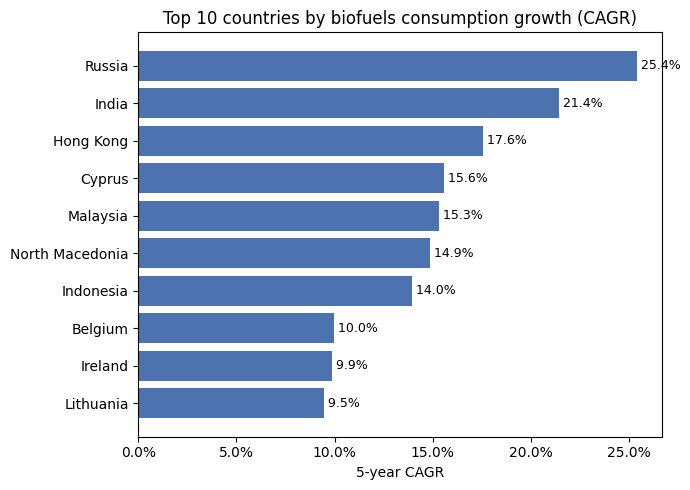

In [3]:
import matplotlib.pyplot as plt
from src.plots import plot_top_n_ranking

fig, ax = plt.subplots(figsize=(7, 5))
plot_top_n_ranking(
    cagr_by_country, value_col="biofuel_cagr_5y", top_n=10, ax=ax,
    xlabel="5-year CAGR", title="Top 10 countries by biofuels consumption growth (CAGR)",
    value_fmt="{:.1%}",
)
plt.tight_layout()
plt.savefig("../reports/figures/cagr_ranking.png", dpi=110)
plt.show()

## KPI 2: penetration (share of primary energy coming from biofuels)

In [4]:
penetration = (
    df[df["year"] == latest_year][["country", "continent", "biofuel_share_energy"]]
    .dropna()
    .sort_values("biofuel_share_energy", ascending=False)
)
penetration.head(10)

,country,continent,biofuel_share_energy
299,Brazil,South America,7.054
1015,Indonesia,Asia,4.034
1315,Luxembourg,Europe,3.847
1090,Ireland,Europe,2.446
1290,Lithuania,Europe,2.282
784,Finland,Europe,2.051
2445,United States,North America,1.987
471,Colombia,South America,1.849
1789,Portugal,Europe,1.663
2245,Thailand,Asia,1.610


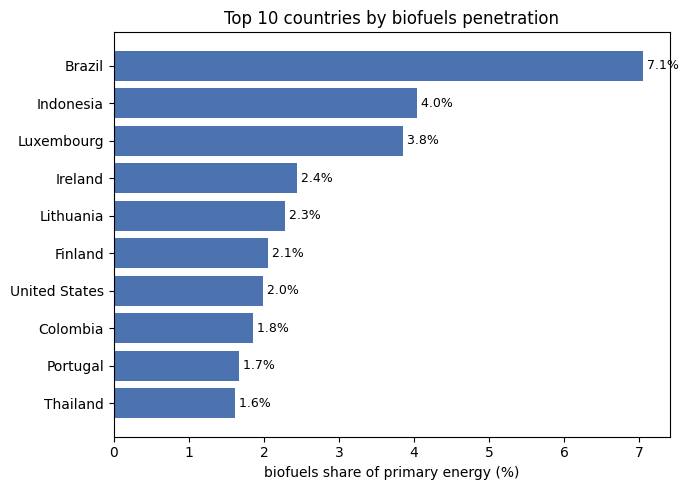

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
plot_top_n_ranking(
    penetration, value_col="biofuel_share_energy", top_n=10, ax=ax,
    xlabel="biofuels share of primary energy (%)", title="Top 10 countries by biofuels penetration",
    value_fmt="{:.1f}%",
)
plt.tight_layout()
plt.savefig("../reports/figures/penetration_ranking.png", dpi=110)
plt.show()

## KPI 3: normalized score and ranking by continent

Min-max normalization within each group (here, continent) puts
continents of very different sizes on a common 0-1 scale, then a
dense rank is built from that score.

In [6]:
latest = df[df["year"] == latest_year].copy()
latest["growth_score"] = latest.groupby("continent")["biofuel_cagr_5y"].transform(
    lambda x: (x - x.min()) / (x.max() - x.min()) if (x.max() - x.min()) != 0 else 0
)
latest["continent_ranking"] = (
    latest.groupby("continent")["growth_score"]
    .rank(method="dense", ascending=False)
    .astype("Int64")
)

ranking_export = latest[[
    "country", "continent", "year", "biofuel_consumption", "biofuel_share_energy",
    "biofuel_cagr_5y", "growth_score", "continent_ranking",
]].sort_values(["continent", "continent_ranking"])

ranking_export.head(15)

,country,continent,year,biofuel_consumption,biofuel_share_energy,biofuel_cagr_5y,growth_score,continent_ranking
24,Algeria,Africa,2024,0.000,0.000,NaN,0.0,1
49,Angola,Africa,2024,0.000,NaN,NaN,0.0,1
396,Chad,Africa,2024,0.000,NaN,NaN,0.0,1
496,Congo,Africa,2024,0.000,NaN,NaN,0.0,1
634,Democratic Republic of Congo,Africa,2024,0.000,NaN,NaN,0.0,1
709,Egypt,Africa,2024,0.000,0.000,NaN,0.0,1
734,Equatorial Guinea,Africa,2024,0.000,NaN,NaN,0.0,1
834,Gabon,Africa,2024,0.000,NaN,NaN,0.0,1
1265,Libya,Africa,2024,0.000,NaN,NaN,0.0,1
1340,Madagascar,Africa,2024,0.000,NaN,NaN,0.0,1


## Business translation of the model's error

Instead of just reporting MAE in TWh: what percentage of actual
consumption the model's typical error represents, split between the
large countries (top-80%) and the rest.

In [7]:
preds = pd.read_csv("../data/processed/predictions_cv.csv")
preds["error_abs"] = (preds["biofuel_consumption_actual"] - preds["biofuel_consumption_predicted"]).abs()

business_summary = preds.groupby("top80_consumer").apply(
    lambda g: pd.Series({
        "countries": g["country"].nunique(),
        "avg_actual_consumption_TWh": g["biofuel_consumption_actual"].mean(),
        "avg_absolute_error_TWh": g["error_abs"].mean(),
        "error_pct_of_consumption": (g["error_abs"].sum() / g["biofuel_consumption_actual"].sum() * 100)
        if g["biofuel_consumption_actual"].sum() > 0 else float("nan"),
    }),
    include_groups=False,
).rename(index={0: "other countries", 1: "top-80% consumption countries"})

business_summary.round(2)

,countries,avg_actual_consumption_TWh,avg_absolute_error_TWh,error_pct_of_consumption
top80_consumer,,,,
other countries,102.0,2.79,0.55,19.81
top-80% consumption countries,5.0,140.80,11.97,8.50


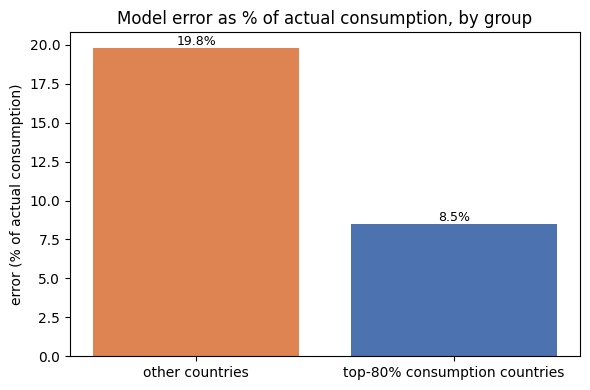

In [8]:
import matplotlib.pyplot as plt
from src.plots import plot_business_error_summary

fig, ax = plt.subplots(figsize=(6, 4))
plot_business_error_summary(business_summary, ax=ax)
plt.tight_layout()
plt.savefig("../reports/figures/business_error_summary.png", dpi=110)
plt.show()

## Export tables for Power BI

In [9]:
import os
os.makedirs("../data/exports", exist_ok=True)

ranking_export.to_csv("../data/exports/country_ranking_powerbi.csv", index=False)
preds.to_csv("../data/exports/predictions_powerbi.csv", index=False)
business_summary.reset_index().rename(columns={"index": "group"}).to_csv(
    "../data/exports/business_summary_powerbi.csv", index=False
)

global_kpis = pd.DataFrame([{
    "year": int(latest_year),
    "world_consumption_TWh": latest["biofuel_consumption"].sum(),
    "countries_with_consumption": int((latest["biofuel_consumption"] > 0).sum()),
    "leading_country": latest.sort_values("biofuel_consumption", ascending=False).iloc[0]["country"],
    "global_avg_cagr_5y": latest["biofuel_cagr_5y"].mean(),
}])
global_kpis.to_csv("../data/exports/global_kpis_powerbi.csv", index=False)
global_kpis

,year,world_consumption_TWh,countries_with_consumption,leading_country,global_avg_cagr_5y
0,2024,1360.019,55,United States,0.002756


## Executive charts (Plotly)

`plot_choropleth_latest_year` (in `src/plots.py`) builds an
interactive world map; it renders fine when running the notebook with
normal internet access, but it isn't exported as a static image here
because Plotly's base map is downloaded from a CDN that's blocked in
this working environment. The bar-chart ranking doesn't depend on any
external map, so it exports without issue.

In [10]:
from src.plots import plot_country_ranking

fig_ranking = plot_country_ranking(df, year=int(latest_year), top_n=15)
fig_ranking.write_image("../reports/figures/top15_countries.png", scale=2)
fig_ranking.show()